In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib
import os

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
df = pd.read_csv('C:/Users/shravan kumar/OneDrive/Desktop/github/credit-card-fraud-detection/data/creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# V1-V28 are already scaled by Kaggle (PCA transformed)
# Only Amount and Time need scaling

scaler_amount = StandardScaler()
scaler_time   = StandardScaler()

df['Amount_scaled'] = scaler_amount.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler_time.fit_transform(df[['Time']])

# Drop original unscaled columns
df = df.drop(['Amount', 'Time'], axis=1)

print("Amount and Time scaled successfully")
print(f"New shape: {df.shape}")
df[['Amount_scaled', 'Time_scaled']].describe().round(3)

Amount and Time scaled successfully
New shape: (284807, 31)


,Amount_scaled,Time_scaled
count,284807.000,284807.000
mean,-0.000,-0.000
std,1.000,1.000
min,-0.353,-1.997
25%,-0.331,-0.855
50%,-0.265,-0.213
75%,-0.045,0.937
max,102.362,1.642


In [4]:
# Reload original to get Time and Amount back for engineering
df_orig = pd.read_csv('C:/Users/shravan kumar/OneDrive/Desktop/github/credit-card-fraud-detection/data/creditcard.csv')

# Hour of day (fraud pattern we saw in EDA)
df['Hour']       = (df_orig['Time'] // 3600) % 24

# Is it a night transaction? (hour 10pm to 6am)
df['Is_night']   = ((df['Hour'] >= 22) | (df['Hour'] <= 6)).astype(int)

# Log of amount (reduces skew)
df['Amount_log'] = np.log1p(df_orig['Amount'])

# Is it a high value transaction? (above 75th percentile)
high_val_thresh  = df_orig['Amount'].quantile(0.75)
df['Is_highval'] = (df_orig['Amount'] > high_val_thresh).astype(int)

# Night + high value combined (suspicious pattern)
df['Night_highval'] = df['Is_night'] * df['Is_highval']

print("New features created:")
print(f"  Hour       : hour of day (0-23)")
print(f"  Is_night   : 1 if between 10pm-6am")
print(f"  Amount_log : log of original amount")
print(f"  Is_highval : 1 if amount > ${high_val_thresh:.2f}")
print(f"  Night_highval : night AND high value")
print(f"\nNew shape: {df.shape}")
df[['Hour', 'Is_night', 'Amount_log', 'Is_highval', 'Night_highval']].head(10)

New features created:
  Hour       : hour of day (0-23)
  Is_night   : 1 if between 10pm-6am
  Amount_log : log of original amount
  Is_highval : 1 if amount > $77.16
  Night_highval : night AND high value

New shape: (284807, 36)


,Hour,Is_night,Amount_log,Is_highval,Night_highval
0,0.0,1,5.014760,1,1
1,0.0,1,1.305626,0,0
2,0.0,1,5.939276,1,1
3,0.0,1,4.824306,1,1
4,0.0,1,4.262539,0,0
5,0.0,1,1.541159,0,0
6,0.0,1,1.790091,0,0
7,0.0,1,3.732896,0,0
8,0.0,1,4.545420,1,1
9,0.0,1,1.543298,0,0


=== Average value per class ===
              Hour  Is_night  Amount_log  Is_highval  Night_highval
Legitimate  14.051     0.191       3.153       0.250          0.036
Fraud       11.646     0.331       2.821       0.354          0.087


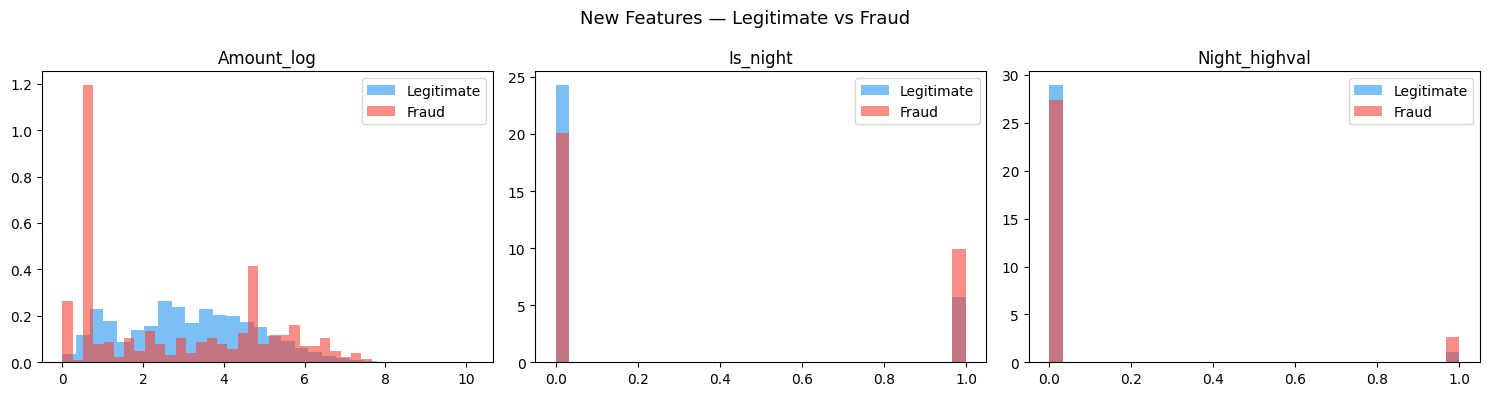

In [5]:
# Compare new features between fraud and legit
new_features = ['Hour', 'Is_night', 'Amount_log', 'Is_highval', 'Night_highval']

comparison = df.groupby('Class')[new_features].mean().round(3)
comparison.index = ['Legitimate', 'Fraud']
print("=== Average value per class ===")
print(comparison)

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat in enumerate(['Amount_log', 'Is_night', 'Night_highval']):
    vals_legit = df[df['Class'] == 0][feat]
    vals_fraud = df[df['Class'] == 1][feat]
    axes[i].hist(vals_legit, bins=30, alpha=0.6,
                 color='#2196F3', label='Legitimate', density=True)
    axes[i].hist(vals_fraud, bins=30, alpha=0.6,
                 color='#F44336', label='Fraud', density=True)
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle('New Features — Legitimate vs Fraud', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features (X) shape : {X.shape}")
print(f"Target  (y) shape  : {y.shape}")
print(f"\nFeature list ({len(X.columns)} total):")
print(X.columns.tolist())
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nFraud percentage: {y.mean()*100:.3f}%")

Features (X) shape : (284807, 35)
Target  (y) shape  : (284807,)

Feature list (35 total):
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled', 'Hour', 'Is_night', 'Amount_log', 'Is_highval', 'Night_highval']

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173%


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps fraud ratio same in both sets
)

print("=== SPLIT RESULTS ===")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\nTraining set fraud count:")
print(y_train.value_counts())
print(f"Training fraud %: {y_train.mean()*100:.3f}%")

print(f"\nTest set fraud count:")
print(y_test.value_counts())
print(f"Test fraud %: {y_test.mean()*100:.3f}%")

=== SPLIT RESULTS ===
X_train : (227845, 35)
X_test  : (56962, 35)

Training set fraud count:
Class
0    227451
1       394
Name: count, dtype: int64
Training fraud %: 0.173%

Test set fraud count:
Class
0    56864
1       98
Name: count, dtype: int64
Test fraud %: 0.172%


Before SMOTE:
  Legitimate: 227,451
  Fraud     : 394

After SMOTE:
  Legitimate: 227,451
  Fraud     : 227,451
  Total     : 454,902

Fraud % after SMOTE: 50.0%


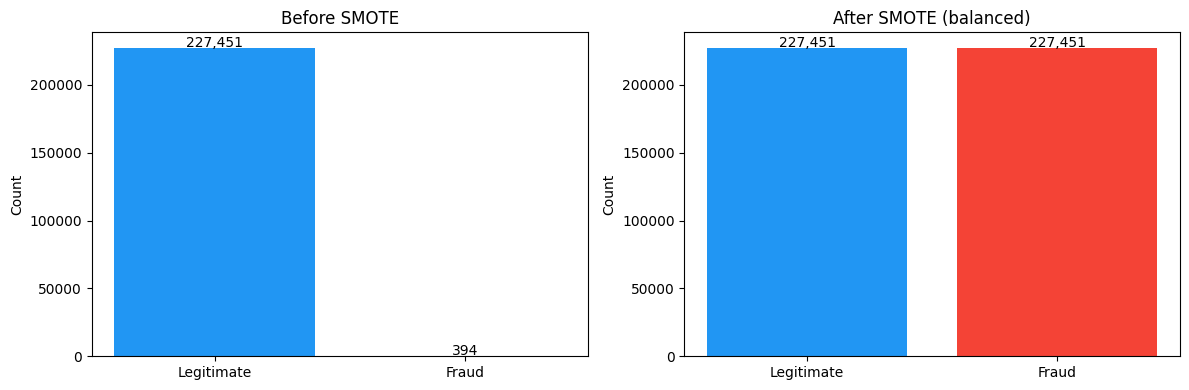


NOTE: SMOTE only applied to TRAINING set.
Test set kept original — never apply SMOTE to test data.


In [8]:
print("Before SMOTE:")
print(f"  Legitimate: {(y_train == 0).sum():,}")
print(f"  Fraud     : {(y_train == 1).sum():,}")

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Legitimate: {(y_train_res == 0).sum():,}")
print(f"  Fraud     : {(y_train_res == 1).sum():,}")
print(f"  Total     : {len(y_train_res):,}")
print(f"\nFraud % after SMOTE: {y_train_res.mean()*100:.1f}%")

# Visualise before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'],
            [(y_train==0).sum(), (y_train==1).sum()],
            color=['#2196F3', '#F44336'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
for i, v in enumerate([(y_train==0).sum(), (y_train==1).sum()]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center')

axes[1].bar(['Legitimate', 'Fraud'],
            [(y_train_res==0).sum(), (y_train_res==1).sum()],
            color=['#2196F3', '#F44336'])
axes[1].set_title('After SMOTE (balanced)')
axes[1].set_ylabel('Count')
for i, v in enumerate([(y_train_res==0).sum(), (y_train_res==1).sum()]):
    axes[1].text(i, v + 500, f'{v:,}', ha='center')

plt.tight_layout()
plt.savefig('../data/07_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNOTE: SMOTE only applied to TRAINING set.")
print("Test set kept original — never apply SMOTE to test data.")

In [9]:
os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Save train/test splits (original, without SMOTE)
joblib.dump(X_train, '../data/X_train.pkl')
joblib.dump(X_test,  '../data/X_test.pkl')
joblib.dump(y_train, '../data/y_train.pkl')
joblib.dump(y_test,  '../data/y_test.pkl')

# Save SMOTE-balanced training data
joblib.dump(X_train_res, '../data/X_train_res.pkl')
joblib.dump(y_train_res, '../data/y_train_res.pkl')

# Save scalers (needed later for the Streamlit app)
joblib.dump(scaler_amount, '../models/scaler_amount.pkl')
joblib.dump(scaler_time,   '../models/scaler_time.pkl')

print("=== ALL FILES SAVED ===")
print("data/X_train.pkl      ← training features (no SMOTE)")
print("data/X_test.pkl       ← test features")
print("data/y_train.pkl      ← training labels (no SMOTE)")
print("data/y_test.pkl       ← test labels")
print("data/X_train_res.pkl  ← training features (SMOTE balanced)")
print("data/y_train_res.pkl  ← training labels (SMOTE balanced)")
print("models/scaler_amount.pkl")
print("models/scaler_time.pkl")

=== ALL FILES SAVED ===
data/X_train.pkl      ← training features (no SMOTE)
data/X_test.pkl       ← test features
data/y_train.pkl      ← training labels (no SMOTE)
data/y_test.pkl       ← test labels
data/X_train_res.pkl  ← training features (SMOTE balanced)
data/y_train_res.pkl  ← training labels (SMOTE balanced)
models/scaler_amount.pkl
models/scaler_time.pkl


In [10]:
print("=" * 50)
print("    PREPROCESSING COMPLETE")
print("=" * 50)
print(f"""
WHAT WAS DONE
  Scaled    : Amount and Time with StandardScaler
  Engineered: 5 new features (Hour, Is_night,
              Amount_log, Is_highval, Night_highval)
  Split     : 80% train / 20% test (stratified)
  Balanced  : SMOTE applied to training set only

FINAL SHAPES
  X_train (original) : {X_train.shape}
  X_train (SMOTE)    : {X_train_res.shape}
  X_test             : {X_test.shape}

NEXT STEP
  → Open 03_baseline.ipynb
""")
print("=" * 50)

    PREPROCESSING COMPLETE

WHAT WAS DONE
  Scaled    : Amount and Time with StandardScaler
  Engineered: 5 new features (Hour, Is_night,
              Amount_log, Is_highval, Night_highval)
  Split     : 80% train / 20% test (stratified)
  Balanced  : SMOTE applied to training set only

FINAL SHAPES
  X_train (original) : (227845, 35)
  X_train (SMOTE)    : (454902, 35)
  X_test             : (56962, 35)

NEXT STEP
  → Open 03_baseline.ipynb

